# **ANN (KFold)**

### Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Suppress TF info/warning logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

# ── Full reproducibility seed block ─────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED']      = str(SEED)  # Python hash randomisation
os.environ['TF_DETERMINISTIC_OPS']  = '1'       # Forces deterministic CPU ops
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'      # Forces deterministic GPU/cuDNN
random.seed(SEED)                               # Python built-in random
np.random.seed(SEED)                            # NumPy
tf.random.set_seed(SEED)                        # TensorFlow / Keras
# ────────────────────────────────────────────────────────────────────────────

print('All imports done ✓')
print(f'TensorFlow: {tf.__version__}')

All imports done ✓
TensorFlow: 2.19.0


### Cell 2 — Load CSV & Build System-Level Aggregate

Run this if the notebook is standalone (separate from Rakesh_FINAL_v6).  
Skip if `df` is already loaded in this session.

In [2]:
df = pd.read_csv('EV_Charging_Load_Demand_Dataset.csv')
print('Raw shape:', df.shape)

df_sys = df.groupby('timestep_sec').agg({
    'minute_of_hour':                  'first',
    'system_total_load_kW':            'first',
    'system_total_vehicles':           'first',
    'system_moving_vehicles':          'first',
    'system_charging_vehicles':        'first',
    'system_waiting_vehicles':         'first',
    'system_avg_speed_ms':             'first',
    'system_avg_soc_percent':          'first',
    'system_avg_moving_speed_ms':      'first',
    'system_avg_moving_soc_percent':   'first',
    'system_avg_charging_soc_percent': 'first',
    'system_avg_charging_duration_sec':'first',
    'station_vehicles_charging':       'sum',
    'station_queue_length':            'sum',
    'station_utilization_percent':     'mean',
    'speed_ms':                        'mean',
    'acceleration_ms2':                'mean',
    'soc_percent':                     'mean',
    'energy_consumed_Wh':              'sum',
}).reset_index().sort_values('timestep_sec').reset_index(drop=True)

X_ann = df_sys.drop(columns=['system_total_load_kW', 'timestep_sec'])
y_ann = df_sys['system_total_load_kW']

print(f'X shape : {X_ann.shape}   ← must be (600, 18)')
print(f'y range : {y_ann.min():.0f} – {y_ann.max():.0f} kW')
print(f'system_total_load_kW in X? {"system_total_load_kW" in X_ann.columns}  ← must be False')

Raw shape: (34020, 25)
X shape : (600, 18)   ← must be (600, 18)
y range : 0 – 1340 kW
system_total_load_kW in X? False  ← must be False


### Cell 3 — Model Builder

**Key changes from v1:**
- `BatchNormalization()` after the first Dense layer — stabilises training on the stepped 0–1340 kW target
- `loss='mse'` — standard for regression (smoother gradients than `'mae'`)
- `Adam(lr=0.001)` — explicit learning rate

In [3]:
def build_ann(input_dim, seed=42):
    """Build ANN. Re-seeding here ensures identical weight init
    every time the function is called, making results reproducible."""
    # Re-seed before every model build so weight initialisation is identical
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),          # stabilises training on stepped load signal
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)                       # regression output — no activation
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',                    # standard regression loss
        metrics=['mae']
    )
    return model

print(f'Model builder defined ✓  (input_dim = {X_ann.shape[1]})')
build_ann(X_ann.shape[1]).summary()

Model builder defined ✓  (input_dim = 18)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 256 (1.00 KB)

### Cell 4 — 5-Fold CV Training Loop  ← ROOT CAUSE FIX HERE

**What was broken in v1:**
```
model.fit(..., validation_split=0.1, callbacks=[EarlyStopping(patience=15)])
```
- `validation_split=0.1` carved 48 samples out of each fold's 480-sample training set
- EarlyStopping monitored loss on those 48 noisy samples → fired at epoch 14
- Model was barely trained → R²=−1.35 (worse than a flat line)

**Fix:**
- Remove `validation_split` — the KFold test fold is already the honest evaluation
- Remove `EarlyStopping` — not needed when we use a fixed, sufficient epoch count
- Use `epochs=150` — enough for 480 samples with batch_size=16 (30 batches/epoch)

In [4]:
# ── KFold — same object as ML pipeline ─────────────────────────────────────
kf_ann = KFold(n_splits=5, shuffle=True, random_state=42)

# Fixed classification bins — identical to ML pipeline Cell 5B
ANN_BINS   = [-1.0, 280.0, 830.0, 1165.0, 1400.0]
ANN_LABELS = ['Low (0–280)', 'Medium (280–830)', 'High (830–1165)', 'Peak (1165+)']

# OOF array — stores predictions for all 600 samples
y_pred_ann_oof = np.zeros(len(y_ann))

# Per-fold storage
r2_list, mae_list, rmse_list, mape_list, acc_list = [], [], [], [], []

print('Running 5-Fold CV for ANN (v2)...\n')
print(f'  Each fold: 480 train  |  120 test  |  epochs=150  |  batch=16')
print(f'  No validation_split, no EarlyStopping inside loop\n')

for fold, (train_idx, test_idx) in enumerate(kf_ann.split(X_ann), 1):

    X_tr_raw = X_ann.iloc[train_idx].values   # 480 samples — ALL used for training
    X_te_raw = X_ann.iloc[test_idx].values    # 120 samples — held out for evaluation
    y_tr     = y_ann.iloc[train_idx].values
    y_te     = y_ann.iloc[test_idx].values

    # Scale: fit on train only, transform test
    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(X_tr_raw)
    X_te    = scaler.transform(X_te_raw)

    # Fresh model each fold
    # Re-seed before each fold so weight init is deterministic
    model = build_ann(X_ann.shape[1], seed=SEED)

    # ── FIX: NO validation_split, NO EarlyStopping ──────────────────────────
    # KFold test fold = honest held-out evaluation → no internal val set needed
    # 150 epochs on 480 samples = 30 batches × 150 = 4500 gradient steps (sufficient)
    model.fit(
        X_tr, y_tr,
        epochs=150,
        batch_size=16,
        verbose=0                      # silent training
    )

    # Predict on held-out test fold
    y_pred_fold = model.predict(X_te, verbose=0).squeeze()
    y_pred_ann_oof[test_idx] = y_pred_fold

    # Per-fold metrics
    r2_f   = r2_score(y_te, y_pred_fold)
    mae_f  = mean_absolute_error(y_te, y_pred_fold)
    rmse_f = np.sqrt(mean_squared_error(y_te, y_pred_fold))
    nz     = y_te != 0
    mape_f = np.mean(np.abs((y_te[nz] - y_pred_fold[nz]) / y_te[nz])) * 100
    acc_f  = 100 - mape_f

    r2_list.append(r2_f);  mae_list.append(mae_f)
    rmse_list.append(rmse_f); mape_list.append(mape_f); acc_list.append(acc_f)

    print(f'  Fold {fold}:  R²={r2_f:.4f}  MAE={mae_f:.2f} kW  '
          f'RMSE={rmse_f:.2f} kW  Acc={acc_f:.2f}%')

print(f'\n5-Fold CV complete ✓')
print(f'  Mean R²  : {np.mean(r2_list):.4f}')
print(f'  Mean MAE : {np.mean(mae_list):.2f} kW')
print(f'  Mean RMSE: {np.mean(rmse_list):.2f} kW')
print(f'  Mean Acc : {np.mean(acc_list):.4f} %')

Running 5-Fold CV for ANN (v2)...

  Each fold: 480 train  |  120 test  |  epochs=150  |  batch=16
  No validation_split, no EarlyStopping inside loop

  Fold 1:  R²=0.9958  MAE=21.45 kW  RMSE=30.12 kW  Acc=89.62%
  Fold 2:  R²=0.9954  MAE=23.08 kW  RMSE=29.89 kW  Acc=95.87%
  Fold 3:  R²=0.9982  MAE=14.21 kW  RMSE=18.69 kW  Acc=97.55%
  Fold 4:  R²=0.9976  MAE=15.90 kW  RMSE=20.73 kW  Acc=97.11%
  Fold 5:  R²=0.9966  MAE=21.39 kW  RMSE=25.69 kW  Acc=96.27%

5-Fold CV complete ✓
  Mean R²  : 0.9967
  Mean MAE : 19.20 kW
  Mean RMSE: 25.02 kW
  Mean Acc : 95.2839 %


### Cell 5 — OOF Metrics (full 600-sample) + Classification

In [5]:
y_arr = np.asarray(y_ann)

# ── Regression metrics on full OOF ──────────────────────────────────────────
mae_ann  = mean_absolute_error(y_arr, y_pred_ann_oof)
mse_ann  = mean_squared_error(y_arr, y_pred_ann_oof)
rmse_ann = np.sqrt(mse_ann)
r2_ann   = r2_score(y_arr, y_pred_ann_oof)

nz       = y_arr != 0
mape_ann = np.mean(np.abs((y_arr[nz] - y_pred_ann_oof[nz]) / y_arr[nz])) * 100
acc_ann  = 100 - mape_ann

print('=== ANN (KFold v2) — OOF Regression Metrics ===')
print(f'  MAE  : {mae_ann:.3f} kW')
print(f'  MSE  : {mse_ann:.3f} kW²')
print(f'  RMSE : {rmse_ann:.3f} kW')
print(f'  MAPE : {mape_ann:.4f} %')
print(f'  R²   : {r2_ann:.4f}')
print(f'  Acc  : {acc_ann:.4f} %')

# ── Classification — fixed bins, pd.cut (identical to ML pipeline) ──────────
y_true_cls  = pd.cut(y_arr,          bins=ANN_BINS, labels=ANN_LABELS, include_lowest=True)
y_pred_clip = np.clip(y_pred_ann_oof, ANN_BINS[0]+1, ANN_BINS[-1]-1)
y_pred_cls  = pd.cut(y_pred_clip,    bins=ANN_BINS, labels=ANN_LABELS, include_lowest=True)

mask   = y_pred_cls.notna()
f1_wtd = f1_score(y_true_cls[mask], y_pred_cls[mask],
                  average='weighted', labels=ANN_LABELS, zero_division=0)
f1_per = f1_score(y_true_cls[mask], y_pred_cls[mask],
                  average=None,      labels=ANN_LABELS, zero_division=0)
f1_low, f1_med, f1_high, f1_peak = (list(f1_per) + [0]*4)[:4]

print(f'\n=== ANN (KFold v2) — Classification Metrics ===')
print(f'  F1 Weighted : {f1_wtd:.4f}')
print(f'  F1 Low      : {f1_low:.4f}')
print(f'  F1 Medium   : {f1_med:.4f}')
print(f'  F1 High     : {f1_high:.4f}')
print(f'  F1 Peak     : {f1_peak:.4f}')

=== ANN (KFold v2) — OOF Regression Metrics ===
  MAE  : 19.205 kW
  MSE  : 647.896 kW²
  RMSE : 25.454 kW
  MAPE : 4.7201 %
  R²   : 0.9967
  Acc  : 95.2799 %

=== ANN (KFold v2) — Classification Metrics ===
  F1 Weighted : 0.9234
  F1 Low      : 0.9853
  F1 Medium   : 0.9127
  F1 High     : 0.8783
  F1 Peak     : 0.9111


### Cell 6 — Append to cls_df (idempotent)

In [6]:
# Safe to re-run — removes old ANN row before appending
if 'cls_df' in globals():
    cls_df = cls_df[~cls_df['Model'].str.startswith('ANN')].copy()
else:
    cls_df = pd.DataFrame(columns=[
        'Model','Accuracy (%)','F1 (weighted)',
        'F1_Low','F1_Medium','F1_High','F1_Peak'
    ])

ann_row = pd.DataFrame([{
    'Model':         'ANN (KFold)',
    'Accuracy (%)':  acc_ann,
    'F1 (weighted)': f1_wtd,
    'F1_Low':        f1_low,
    'F1_Medium':     f1_med,
    'F1_High':       f1_high,
    'F1_Peak':       f1_peak,
}])
cls_df = pd.concat([cls_df, ann_row], ignore_index=True)

if 'reg_df' in globals():
    reg_df = reg_df[reg_df['Model'] != 'ANN (KFold)'].copy()
    reg_df = pd.concat([reg_df, pd.DataFrame([{
        'Model':'ANN (KFold)','MAE':mae_ann,'MSE':mse_ann,
        'RMSE':rmse_ann,'MAPE (%)':mape_ann,'R²':r2_ann,
    }])], ignore_index=True)

print('cls_df updated ✓')
print('Models in table:', cls_df['Model'].tolist())

cls_df updated ✓
Models in table: ['ANN (KFold)']


/tmp/ipykernel_4179/3581941907.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cls_df = pd.concat([cls_df, ann_row], ignore_index=True)


### Cell 7 — Print Final Metrics Table

In [7]:
print('=' * 75)
print('  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1   (5-Fold CV)')
print('  Accuracy (%) = 100 − MAPE   [non-zero samples only]')
print('=' * 75)
hdr = (f"{'Model':<22} {'Acc (%)':>10} {'F1-Wtd':>9} "
       f"{'F1-Low':>8} {'F1-Med':>8} {'F1-High':>8} {'F1-Peak':>8}")
print(hdr)
print('─' * 75)
for _, r in cls_df.iterrows():
    print(f"{r['Model']:<22} {float(r['Accuracy (%)']):>10.4f} {float(r['F1 (weighted)']):>9.4f} "
          f"{float(r['F1_Low']):>8.4f} {float(r['F1_Medium']):>8.4f} "
          f"{float(r['F1_High']):>8.4f} {float(r['F1_Peak']):>8.4f}")
print('=' * 75)
print('Best Accuracy →', cls_df.loc[cls_df['Accuracy (%)'].astype(float).idxmax(), 'Model'])
print('Best F1       →', cls_df.loc[cls_df['F1 (weighted)'].astype(float).idxmax(), 'Model'])

  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1   (5-Fold CV)
  Accuracy (%) = 100 − MAPE   [non-zero samples only]
Model                     Acc (%)    F1-Wtd   F1-Low   F1-Med  F1-High  F1-Peak
───────────────────────────────────────────────────────────────────────────
ANN (KFold)               95.2799    0.9234   0.9853   0.9127   0.8783   0.9111
Best Accuracy → ANN (KFold)
Best F1       → ANN (KFold)


### Cell 8 — Actual vs Predicted Scatter Plot

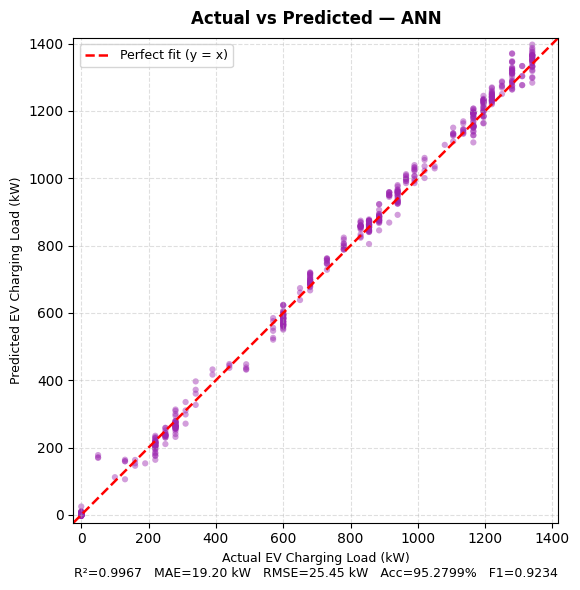

Saved → scatter_ann_kfold.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

lims = [min(y_arr.min(), y_pred_ann_oof.min()) - 20,
        max(y_arr.max(), y_pred_ann_oof.max()) + 20]

ax.scatter(y_arr, y_pred_ann_oof,
           color='#9C27B0', alpha=0.45, s=20, edgecolors='none')
ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')

# ax.set_title('Actual vs Predicted — ANN (KFold, 5-Fold CV)',
ax.set_title('Actual vs Predicted — ANN',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual EV Charging Load (kW)\n'
    f'R²={r2_ann:.4f}   MAE={mae_ann:.2f} kW   RMSE={rmse_ann:.2f} kW   '
    f'Acc={acc_ann:.4f}%   F1={f1_wtd:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted EV Charging Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter_ann_kfold.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_ann_kfold.png')

### Cell 9 — Download

In [9]:
from google.colab import files
files.download('scatter_ann_kfold.png')
print('Downloaded ✓')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded ✓
